# Week 6 — LLM Feature Extraction for M&A Prediction

**Goal:** Test whether a generative LLM (OpenAI `gpt-5-mini` / `gpt-5`) can read a company's
pre-announcement news and extract *strategic-intent* signals — "exploring strategic
alternatives," activist pressure, management turnover, distress — that beat the week-4
classic-NLP stack at predicting M&A.

### Pipeline
```
ma_event_news.csv        ->  extract_llm_features.py           ->  data/raw/llm/*.csv   ->  this notebook
(GDELT+EDGAR headlines,      1 structured-JSON call per            resumable, $-capped      feature sets A/B/C
 same cache as week4)        (event, window): 17 fields            per-call cache           -> same models as week4
```

- **Feature set A** — the week-4 classic-NLP stack (VADER, FinBERT, log-odds terms, NMF
  topics, momentum, EDGAR filing mix), recomputed in this notebook **on the exact same
  scraped corpus** the LLM reads.
- **Feature set B** — the 12 numeric LLM signals per (event, window).
- **Feature set C** — A + B combined.

Same experimental design as week4: `pre` (label=1) = [announcement−97d, announcement−7d],
`baseline` (label=0) = same window shifted back 180d for the **same company** (paired design);
time-based 80/20 split; LogisticRegressionCV / Random Forest / Gradient Boosting.

### ⚠️ Three validity threats, each tested before results are trusted
| # | Threat | Where tested |
|---|--------|--------------|
| 1 | **Training-data look-ahead** — the LLM's training corpus contains news about most of these 2016–2025 deals; it may "remember" outcomes rather than read the text | §7a memorization probe (no news shown), §7b company-name-masking A/B, post-knowledge-cutoff holdout |
| 2 | **Score arbitrariness** — "activist_pressure = 7" is not a measurement; the same input can score differently on a re-run | §7c repeat-consistency (re-score the same windows, measure variance) |
| 3 | **Small-sample noise** — a few hundred test rows swing AUC by ±0.05+ | bootstrap 95% CIs on every reported AUC; paired Wilcoxon as primary evidence |

This notebook **never calls the OpenAI API** — it only loads the local caches written by
`code/extract_llm_features.py` (so teammates can run it with no API key). Each analysis cell
prints the CLI command to top up the cache it reads.

In [1]:
import subprocess, sys
for pkg in ['vaderSentiment', 'scikit-learn', 'transformers', 'torch', 'openai', 'python-dotenv']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('✓ Dependencies ready')

✓ Dependencies ready


In [2]:
import os, re, json, warnings, random, sys
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import NMF
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120})

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
CODE_DIR     = PROJECT_ROOT / 'code'
EVENTS_PATH  = PROJECT_ROOT / 'data' / 'raw' / 'events' / 'ma_events.csv'
NEWS_CACHE   = PROJECT_ROOT / 'data' / 'raw' / 'news' / 'ma_event_news.csv'      # download_news_ma_events.py
LLM_SCORES   = PROJECT_ROOT / 'data' / 'raw' / 'llm' / 'ma_event_llm_scores.csv' # extract_llm_features.py
LLM_PROBE    = PROJECT_ROOT / 'data' / 'raw' / 'llm' / 'ma_event_llm_probe.csv'
FEATURES_A_OUT   = PROJECT_ROOT / 'data' / 'interim' / 'ma_news_features_week6.csv'
LLM_FEATURES_OUT = PROJECT_ROOT / 'data' / 'interim' / 'ma_llm_features.csv'
OUT_DIR      = PROJECT_ROOT / 'outputs' / 'week6'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reuse the exact same helpers/constants as the scraper + LLM scorer (no drift)
sys.path.insert(0, str(CODE_DIR))
from download_news_ma_events import clean_name, get_window_dates
from extract_llm_features import (NOISE_RE, JUNK_DOMAINS, PROMPT_VERSION, SCORE_FIELDS,
                                  SIGNAL_FIELDS_0_10, MODEL_KNOWLEDGE_CUTOFF, FTYPE_RE)

# ── Experiment config (must match the scraping + extraction runs) ─────────
LOOKBACK_DAYS   = 90
BLACKOUT_DAYS   = 7
NEGATIVE_SHIFT  = 180
RANDOM_SEED     = 42
N_TOPICS        = 8
PRIMARY_MODEL   = 'gpt-5-mini'
SENSITIVITY_MODEL = 'gpt-5'

LLM_NUMERIC = [f'llm_{f}' for f in SCORE_FIELDS]   # the 12 numeric LLM fields
DECK = {}                                          # stats collected for the deck (§10)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('✓ Imports complete — this notebook makes NO API calls (loads local caches only)')

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports complete — this notebook makes NO API calls (loads local caches only)


## 2. Data Overview

Same ground truth as week4: S&P Global US deals **≥ $1B, 2016–2026**. News was re-scraped
on this machine with `download_news_ma_events.py` (seed 42 — the same deterministic sample
the week-4 cache was built from), because the raw news caches are gitignored and live
per-machine. Top up any time:

```bash
python code/download_news_ma_events.py --n-events 300
```

In [3]:
events = pd.read_csv(EVENTS_PATH, parse_dates=['announcement_date', 'close_date'])
news_df = pd.read_csv(NEWS_CACHE, dtype=str).fillna('')

print(f'M&A events (≥$1B, 2016-2026):   {len(events):>8,}')
print(f'Date range:                     {events["announcement_date"].min().date()} → {events["announcement_date"].max().date()}')
print(f'\nLocal news cache: {len(news_df):,} rows, {news_df["transaction_id"].nunique()} events')
articles_only = news_df[news_df['title'] != '']
print(f'  Articles with text:     {len(articles_only):,}')
print(f'  Events with ≥1 article: {articles_only["transaction_id"].nunique()}')
print(f'  By source:              {articles_only["source"].value_counts().to_dict()}')

DECK['n_events_total'] = int(len(events))
DECK['n_events_cached'] = int(news_df['transaction_id'].nunique())
DECK['n_articles_cached'] = int(len(articles_only))

M&A events (≥$1B, 2016-2026):      2,673
Date range:                     2016-06-24 → 2026-06-16

Local news cache: 1,251 rows, 59 events
  Articles with text:     1,198
  Events with ≥1 article: 37
  By source:              {'gdelt': 758, 'edgar': 440}


## 3. Feature Set A — the week-4 classic-NLP stack, recomputed on this corpus

To make the A-vs-B comparison fair, the week-4 feature stack is recomputed **on the exact
corpus the LLM reads** (same scrape, same noise filter): VADER, FinBERT, log-odds
distinctive terms (company-masked), NMF topics (company-masked), within-window momentum,
and EDGAR filing structure. The full-article-text layer (week4 §3f) is skipped — its
enrichment cache wasn't built on this machine and week4 showed it degrades gracefully.

The bot-spam noise filter (`NOISE_RE` + `JUNK_DOMAINS`) is now **imported from
`extract_llm_features.py`** so the classic stack and the LLM provably score the same text.

In [4]:
# ── VADER + keyword baseline (week4 cell 13, same source split + noise filter) ──
MA_KW_RE = re.compile(
    r'\b(merger|acqui|takeover|buyout|buy.?out|strategic|bid|offer|'
    r'private equity|stake|transaction|bought|sold|purchase)\b',
    re.IGNORECASE
)
sia = SentimentIntensityAnalyzer()

def score(title: str) -> dict:
    if not title or not str(title).strip():
        return {'compound': 0.0, 'pos': 0.0, 'neg': 0.0, 'neu': 1.0, 'has_ma_kw': 0}
    s = sia.polarity_scores(str(title))
    s['has_ma_kw'] = int(bool(MA_KW_RE.search(str(title))))
    return s

edgar_df = news_df[(news_df['source'] == 'edgar') & (news_df['title'].str.strip() != '')].copy()
gdelt_df = news_df[(news_df['source'] == 'gdelt') & (news_df['title'].str.strip() != '')].copy()

is_noise = gdelt_df['title'].str.contains(NOISE_RE, regex=True) | gdelt_df['domain'].isin(JUNK_DOMAINS)
print(f'Noise filter: dropping {is_noise.sum():,} of {len(gdelt_df):,} GDELT headlines ({is_noise.mean():.1%})')
valid = gdelt_df[~is_noise].copy()

scores  = valid['title'].apply(score)
sent_df = pd.concat([valid.reset_index(drop=True), pd.DataFrame(scores.tolist())], axis=1)
sent_df['label'] = sent_df['label'].astype(int)
print(f'Scored {len(sent_df):,} GDELT headlines with VADER')
print(sent_df.groupby('window')[['compound', 'has_ma_kw']].mean().round(4))

Noise filter: dropping 125 of 758 GDELT headlines (16.5%)
Scored 633 GDELT headlines with VADER
          compound  has_ma_kw
window                       
baseline    0.1002     0.0126
pre         0.1067     0.0222


In [5]:
# ── FinBERT (week4 cell 16) — finance-tuned sentiment, local CPU ───────────
from transformers import pipeline
print('Loading FinBERT (ProsusAI/finbert)...')
finbert = pipeline('text-classification', model='ProsusAI/finbert', top_k=None,
                   truncation=True, device=-1)

def finbert_score_batch(titles: list, batch_size: int = 32) -> pd.DataFrame:
    rows = []
    texts = [t if t and str(t).strip() else '.' for t in titles]
    for i in tqdm(range(0, len(texts), batch_size), desc='FinBERT'):
        out = finbert(texts[i:i + batch_size], batch_size=batch_size)
        for s in out:
            rows.append({x['label']: x['score'] for x in s})
    return pd.DataFrame(rows)

fb = finbert_score_batch(sent_df['title'].tolist())
sent_df['finbert_positive'] = fb['positive'].values
sent_df['finbert_negative'] = fb['negative'].values
sent_df['finbert_compound'] = sent_df['finbert_positive'] - sent_df['finbert_negative']
print(sent_df.groupby('window')[['compound', 'finbert_compound']].mean().round(4))

Loading FinBERT (ProsusAI/finbert)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 34345.93it/s]

FinBERT:   0%|          | 0/20 [00:00<?, ?it/s]

FinBERT:   5%|▌         | 1/20 [00:00<00:05,  3.41it/s]

...

FinBERT:  90%|█████████ | 18/20 [00:09<00:01,  1.32it/s]

FinBERT:  95%|█████████▌| 19/20 [00:10<00:00,  1.55it/s]

FinBERT: 100%|██████████| 20/20 [00:10<00:00,  1.87it/s]

FinBERT: 100%|██████████| 20/20 [00:10<00:00,  1.88it/s]

          compound  finbert_compound
window                              
baseline    0.1002            0.0910
pre         0.1067            0.1082


In [6]:
# ── Log-odds distinctive terms, company-masked (week4 cell 18) ─────────────
from functools import lru_cache
TOKEN_PATTERN = r"(?u)\b[a-zA-Z]{3,}\b"

@lru_cache(maxsize=None)
def _company_mask_pattern(company_name: str):
    words = [w for w in clean_name(company_name).split() if len(w) >= 3]
    if not words:
        return None
    return re.compile(r'\b(' + '|'.join(re.escape(w) for w in words) + r')\b', re.IGNORECASE)

def _mask_company(row):
    pat = _company_mask_pattern(row['company_name'])
    return pat.sub(' ', str(row['title'])) if pat else str(row['title'])

sent_df['title_masked'] = sent_df.apply(_mask_company, axis=1)

count_vec = CountVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                            token_pattern=TOKEN_PATTERN)
X_counts = count_vec.fit_transform(sent_df['title_masked'])
vocab = count_vec.get_feature_names_out()
pre_mask, base_mask = (sent_df['window'] == 'pre').values, (sent_df['window'] == 'baseline').values
counts_pre  = np.asarray(X_counts[pre_mask].sum(axis=0)).ravel()
counts_base = np.asarray(X_counts[base_mask].sum(axis=0)).ravel()
n_pre, n_base = counts_pre.sum(), counts_base.sum()
alpha0 = 1000.0
background = (counts_pre + counts_base) / (counts_pre.sum() + counts_base.sum())
alpha_w = background * alpha0

def log_odds_z(y_i, y_j, n_i, n_j, a_w, a0):
    delta = (np.log((y_i + a_w) / (n_i + a0 - y_i - a_w))
             - np.log((y_j + a_w) / (n_j + a0 - y_j - a_w)))
    return delta / np.sqrt(1.0 / (y_i + a_w) + 1.0 / (y_j + a_w))

z_scores = log_odds_z(counts_pre, counts_base, n_pre, n_base, alpha_w, alpha0)
logodds_df = pd.DataFrame({'term': vocab, 'z_score': z_scores,
                           'count_pre': counts_pre, 'count_baseline': counts_base}
                          ).sort_values('z_score', ascending=False)
print('Top 10 PRE-window terms (company names masked):')
print(logodds_df.head(10)[['term', 'z_score']].to_string(index=False))
distinctive_terms = logodds_df.loc[logodds_df['z_score'].abs() >= 2.0, 'term'].tolist()
_distinctive_pattern = (re.compile(r'\b(' + '|'.join(re.escape(t) for t in distinctive_terms) + r')\b',
                                   re.IGNORECASE) if distinctive_terms else None)
sent_df['has_distinctive_term'] = sent_df['title_masked'].apply(
    lambda t: int(bool(_distinctive_pattern.search(str(t)))) if _distinctive_pattern else 0)
print(f'{len(distinctive_terms)} terms pass |z| >= 2.0')

Top 10 PRE-window terms (company names masked):
         term  z_score
        women 2.934704
         self 2.702567
         list 2.650659
       forbes 2.553599
      richest 2.553599
 richest self 2.553599
       origin 2.553599
   self women 2.553599
indian origin 2.553599
       indian 2.338817
22 terms pass |z| >= 2.0


In [7]:
# ── NMF topics on masked headlines (week4 cell 20) ─────────────────────────
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), stop_words='english', min_df=5, max_df=0.5,
                            token_pattern=TOKEN_PATTERN)
X_tfidf = tfidf_vec.fit_transform(sent_df['title_masked'])
nmf = NMF(n_components=N_TOPICS, init='nndsvda', random_state=RANDOM_SEED, max_iter=400)
topic_loadings = nmf.fit_transform(X_tfidf)
topic_terms = tfidf_vec.get_feature_names_out()
for k in range(N_TOPICS):
    top_idx = nmf.components_[k].argsort()[::-1][:8]
    print(f'  Topic {k}: ' + ', '.join(topic_terms[i] for i in top_idx))
for k in range(N_TOPICS):
    sent_df[f'topic_{k}'] = topic_loadings[:, k]

  Topic 0: new, board, river, systems, team, appoints, day, announces
  Topic 1: market, growth, global, analysis, forecast, cagr, report, organic
  Topic 2: women, list, self, indian, indian origin, origin, richest, richest self
  Topic 3: stocks, buy, motley, motley fool, fool, energy, stocks buy, renewable
  Topic 4: news, business, national, national news, daily, service, team, preview
  Topic 5: nova, minerals, nova minerals, estelle, limited, minerals limited, alaska, air
  Topic 6: aew, dynamite, aew dynamite, match, week, world, update, report
  Topic 7: trump, brother, robert, president, brother robert, donald, donald trump, house


In [8]:
# ── Momentum + EDGAR filing structure (week4 cell 22) ──────────────────────
sent_df = sent_df.merge(events[['transaction_id', 'announcement_date']], on='transaction_id', how='left')

def _window_bounds(row):
    start, end = get_window_dates(row['announcement_date'], row['window'],
                                  LOOKBACK_DAYS, BLACKOUT_DAYS, NEGATIVE_SHIFT)
    return pd.Timestamp(start), pd.Timestamp(end)

_bounds = sent_df.apply(_window_bounds, axis=1, result_type='expand')
sent_df['_win_start'], sent_df['_win_end'] = _bounds[0], _bounds[1]
sent_df['_art_date'] = pd.to_datetime(sent_df['date'].str[:8], format='%Y%m%d', errors='coerce')
span = (sent_df['_win_end'] - sent_df['_win_start']).dt.days.clip(lower=1)
sent_df['rel_pos'] = ((sent_df['_art_date'] - sent_df['_win_start']).dt.days / span).clip(0, 1)

def momentum(group: pd.DataFrame) -> dict:
    g = group.dropna(subset=['rel_pos'])
    if len(g) < 3:
        return {'late_share': 0.0, 'sentiment_trend': 0.0}
    slope = np.polyfit(g['rel_pos'], g['compound'], 1)[0] if g['rel_pos'].nunique() > 1 else 0.0
    return {'late_share': (g['rel_pos'] > (2 / 3)).mean(), 'sentiment_trend': slope}

mom_rows = []
for (txn, window), g in sent_df.groupby(['transaction_id', 'window']):
    d = momentum(g); d.update(transaction_id=txn, window=window); mom_rows.append(d)
momentum_df = pd.DataFrame(mom_rows)

edgar_df['filing_type'] = edgar_df['title'].apply(
    lambda t: FTYPE_RE.match(t).group(1) if FTYPE_RE.match(t) else 'UNK')
edgar_df['is_deal_filing'] = (edgar_df['filing_type'] != '8-K').astype(int)
edg_rows = []
for (txn, window), g in edgar_df.groupby(['transaction_id', 'window']):
    edg_rows.append(dict(transaction_id=txn, window=window,
                         edgar_filing_count=len(g),
                         edgar_deal_filing_count=int(g['is_deal_filing'].sum()),
                         edgar_deal_filing_ratio=g['is_deal_filing'].mean()))
edgar_feat_df = pd.DataFrame(edg_rows)
print(f'Momentum: {len(momentum_df):,} windows | EDGAR features: {len(edgar_feat_df):,} windows')
print('EDGAR filing types:', edgar_df['filing_type'].value_counts().to_dict())

Momentum: 29 windows | EDGAR features: 60 windows
EDGAR filing types: {'8-K': 424, 'DEFM14A': 16}


In [9]:
# ── Aggregate to one row per (transaction_id, window) (week4 cell 26) ──────
def aggregate(group: pd.DataFrame) -> dict:
    n = len(group)
    if n == 0:
        base = dict(news_count=0, avg_sentiment=0.0, std_sentiment=0.0,
                    pos_ratio=0.0, neg_ratio=0.0, ma_keyword_count=0,
                    ma_keyword_ratio=0.0, max_sentiment=0.0, min_sentiment=0.0,
                    avg_finbert_compound=0.0, std_finbert_compound=0.0,
                    avg_finbert_positive=0.0, avg_finbert_negative=0.0,
                    distinctive_term_ratio=0.0)
        base.update({f'topic_{k}_mean': 0.0 for k in range(N_TOPICS)})
        return base
    d = dict(
        news_count       = n,
        avg_sentiment    = group['compound'].mean(),
        std_sentiment    = group['compound'].std(ddof=0),
        pos_ratio        = (group['compound'] > 0.05).mean(),
        neg_ratio        = (group['compound'] < -0.05).mean(),
        ma_keyword_count = int(group['has_ma_kw'].sum()),
        ma_keyword_ratio = group['has_ma_kw'].mean(),
        max_sentiment    = group['compound'].max(),
        min_sentiment    = group['compound'].min(),
        avg_finbert_compound = group['finbert_compound'].mean(),
        std_finbert_compound = group['finbert_compound'].std(ddof=0),
        avg_finbert_positive = group['finbert_positive'].mean(),
        avg_finbert_negative = group['finbert_negative'].mean(),
        distinctive_term_ratio = group['has_distinctive_term'].mean(),
    )
    for k in range(N_TOPICS):
        d[f'topic_{k}_mean'] = group[f'topic_{k}'].mean()
    return d

feat_rows = []
for (txn_id, window), grp in sent_df.groupby(['transaction_id', 'window']):
    f = aggregate(grp)
    f.update(transaction_id=txn_id, window=window, label=int(grp['label'].iloc[0]))
    feat_rows.append(f)

zero_events = set(zip(news_df['transaction_id'], news_df['window'])) - set(zip(sent_df['transaction_id'], sent_df['window']))
zero_lookup = news_df.drop_duplicates(subset=['transaction_id', 'window'])[['transaction_id', 'window', 'label']]
for _, row in zero_lookup[[(t, w) in zero_events for t, w in zip(zero_lookup['transaction_id'], zero_lookup['window'])]].iterrows():
    f = aggregate(pd.DataFrame())
    f.update(transaction_id=row['transaction_id'], window=row['window'], label=int(row['label']))
    feat_rows.append(f)

feat_df = pd.DataFrame(feat_rows)
feat_df = feat_df.merge(momentum_df, on=['transaction_id', 'window'], how='left')
feat_df = feat_df.merge(edgar_feat_df, on=['transaction_id', 'window'], how='left')
NEW_COLS = ['late_share', 'sentiment_trend', 'edgar_filing_count',
            'edgar_deal_filing_count', 'edgar_deal_filing_ratio']
feat_df[NEW_COLS] = feat_df[NEW_COLS].fillna(0.0)
meta = events[['transaction_id', 'announcement_date', 'primary_industry',
               'deal_value_usd', 'transaction_type']].drop_duplicates('transaction_id')
feat_df = feat_df.merge(meta, on='transaction_id', how='left')
feat_df['has_news'] = (feat_df['news_count'] > 0) | (feat_df['edgar_filing_count'] > 0)
feat_df.to_csv(FEATURES_A_OUT, index=False)
print(f'Feature set A: {feat_df.shape} -> {FEATURES_A_OUT.relative_to(PROJECT_ROOT)}')
print(f'  pre rows: {(feat_df.window=="pre").sum()}, baseline rows: {(feat_df.window=="baseline").sum()}')
print(f'  windows with any coverage: {feat_df["has_news"].sum()}')

Feature set A: (118, 35) -> data/interim/ma_news_features_week6.csv
  pre rows: 59, baseline rows: 59
  windows with any coverage: 65


In [10]:
# ── Cross-check: our re-scraped A-features vs the committed week-4 run ─────
# (different event samples/scrape dates -> expect similar REGIMES, not identical numbers)
wk4_path = PROJECT_ROOT / 'data' / 'interim' / 'ma_news_features.csv'
if wk4_path.exists():
    wk4 = pd.read_csv(wk4_path)
    shared = ['news_count', 'avg_sentiment', 'ma_keyword_ratio', 'avg_finbert_compound',
              'late_share', 'edgar_deal_filing_ratio']
    rows = []
    for c in shared:
        if c in wk4.columns:
            gap_ours = feat_df.loc[feat_df.label == 1, c].mean() - feat_df.loc[feat_df.label == 0, c].mean()
            gap_wk4  = wk4.loc[wk4.label == 1, c].mean() - wk4.loc[wk4.label == 0, c].mean()
            rows.append(dict(feature=c, pre_minus_baseline_ours=round(gap_ours, 4),
                             pre_minus_baseline_week4=round(gap_wk4, 4)))
    print('Label gap (pre − baseline) — this scrape vs committed week-4 features:')
    print(pd.DataFrame(rows).to_string(index=False))
else:
    print('Committed week-4 feature matrix not found; skipping cross-check.')

Label gap (pre − baseline) — this scrape vs committed week-4 features:
                feature  pre_minus_baseline_ours  pre_minus_baseline_week4
             news_count                  -0.0169                   -0.1022
          avg_sentiment                   0.0134                   -0.0028
       ma_keyword_ratio                   0.0029                    0.0020
   avg_finbert_compound                   0.0108                   -0.0055
             late_share                   0.0170                   -0.0037
edgar_deal_filing_ratio                   0.0095                    0.0045


## 4. Feature Set B — what we actually send the LLM, and what comes back

`code/extract_llm_features.py` sends **one chat-completions call per (event, window)**:
the window's noise-filtered GDELT headlines (deduped, ≤60, tagged `[dNN]` = day-in-window)
plus a one-line SEC-filing summary — and receives a **strict-JSON** vector of 17 fields
(10 precursor signals 0–10, overall `acquisition_likelihood` 0–100, quality/theme/
recognition fields, verbatim evidence quotes, one-sentence rationale).

**Leakage rules:** the announcement date is never sent; the window is described only by its
end **month**; the model is never told pre vs baseline; `--mask-names` additionally blanks
the company's own name.

Top up / re-run (resumable, cost-capped):
```bash
python code/extract_llm_features.py                      # main: gpt-5-mini, unmasked
python code/extract_llm_features.py --mask-names         # contamination A/B variant
python code/extract_llm_features.py --task probe         # memorization probe (§7a)
python code/extract_llm_features.py --model gpt-5 --limit-events 100   # sensitivity
```

In [11]:
# ── Load the LLM score cache; parse numeric features ────────────────────────
if not LLM_SCORES.exists():
    raise RuntimeError('No LLM scores yet. Run: python code/extract_llm_features.py')
llm_raw = pd.read_csv(LLM_SCORES, dtype=str).fillna('')
ok = llm_raw[llm_raw['parse_ok'] == '1'].copy()
# last write wins per resume key (failed earlier attempts may precede a success)
ok = ok.drop_duplicates(subset=['transaction_id', 'window', 'task', 'model',
                                'prompt_version', 'variant', 'run_tag'], keep='last')
for c in LLM_NUMERIC:
    ok[c] = pd.to_numeric(ok[c], errors='coerce')
ok['cost_usd'] = pd.to_numeric(ok['cost_usd'], errors='coerce').fillna(0.0)
ok['label_int'] = pd.to_numeric(ok['label'], errors='coerce')

print('LLM cache coverage (rows scored ok, by run):')
cov = ok.groupby(['task', 'model', 'variant', 'run_tag']).agg(
    windows=('transaction_id', 'size'), events=('transaction_id', 'nunique'),
    cost_usd=('cost_usd', 'sum')).round(3)
print(cov.to_string())

fail = llm_raw[llm_raw['parse_ok'] != '1']
print(f'\nFailed/refused calls (retryable): {len(fail)}')
total_cost = ok['cost_usd'].sum() + pd.to_numeric(fail['cost_usd'], errors='coerce').fillna(0).sum()
in_tok  = pd.to_numeric(llm_raw['input_tokens'], errors='coerce').fillna(0).sum()
out_tok = pd.to_numeric(llm_raw['output_tokens'], errors='coerce').fillna(0).sum()
print(f'Total spend in this cache: ${total_cost:.2f}  ({in_tok:,.0f} input + {out_tok:,.0f} output tokens)')

# Committed derived matrix so teammates can run this notebook with no API key:
ok.drop(columns=['json_raw'], errors='ignore').to_csv(LLM_FEATURES_OUT, index=False)
print(f'Parsed matrix -> {LLM_FEATURES_OUT.relative_to(PROJECT_ROOT)}')

DECK['llm_total_cost'] = float(round(total_cost, 2))
DECK['llm_calls_ok'] = int(len(ok))
DECK['llm_tokens'] = int(in_tok + out_tok)

LLM cache coverage (rows scored ok, by run):


                                     windows  events  cost_usd
task    model      variant  run_tag                           
day0    gpt-5-mini unmasked r1            11      11     0.010
extract gpt-5      unmasked r1            65      37     0.215
        gpt-5-mini masked   r1            65      37     0.050
                   unmasked r1            65      37     0.050
                            r2            44      25     0.033

Failed/refused calls (retryable): 0
Total spend in this cache: $0.36  (300,014 input + 55,055 output tokens)
Parsed matrix -> data/interim/ma_llm_features.csv


In [12]:
# ── Transparency: the EXACT prompt for one real window + what came back ────
from extract_llm_features import (build_window_corpus, pack_headlines,
                                  build_messages_extract, edgar_summary_line)
main = ok[(ok.task == 'extract') & (ok.model == PRIMARY_MODEL) &
          (ok.variant == 'unmasked') & (ok.run_tag == 'r1')]
# pick a pre-window with substantive coverage
demo = main[(main.window == 'pre') & (main.llm_headline_information_quality >= 5)]
demo = (demo.sort_values('llm_acquisition_likelihood', ascending=False).iloc[0]
        if len(demo) else main.iloc[0])
corpus = build_window_corpus(news_df[news_df.transaction_id == demo.transaction_id], events)
item = corpus[(demo.transaction_id, demo.window)]
lines, n_total = pack_headlines(item['gdelt'], 60, None)
msgs = build_messages_extract(item['company_name'], item['window_end_month'],
                              item['period_days'], lines, n_total,
                              edgar_summary_line(item['edgar_types']), False)
print('═' * 100)
print(f"WHAT WE SEND — {demo.company_name!r}, window={demo.window} (label={demo.label})")
print('═' * 100)
for m in msgs:
    print(f"\n[{m['role'].upper()}]\n{m['content'][:2600]}")
print('\n' + '═' * 100)
print('WHAT COMES BACK (strict JSON, one call):')
print('═' * 100)
demo_json = json.loads(demo.json_raw)
print(json.dumps(demo_json, indent=2)[:1800])
DECK['example_company'] = str(demo.company_name)
DECK['example_window'] = str(demo.window)
# Feed the REAL prompt/response to the deck (slide 4), truncated to fit its panels
user_lines = msgs[1]['content'].split('\n')
DECK['example_prompt_lines'] = [l[:62] for l in user_lines[:5] + user_lines[5:16]][:16]
resp_keep = ['ma_rumor_intensity', 'strategic_alternatives_review', 'activist_pressure',
             'management_instability', 'financial_distress', 'acquisition_likelihood',
             'dominant_theme', 'recognized_company', 'recognized_deal']
resp_small = {k: demo_json[k] for k in resp_keep if k in demo_json}
resp_small['evidence_quotes'] = [q[:48] + '…' for q in (demo_json.get('evidence_quotes') or [])[:2]]
resp_small['rationale'] = (demo_json.get('rationale') or '')[:110] + '…'
DECK['example_response_lines'] = [l[:60] for l in json.dumps(resp_small, indent=1).split('\n')][:18]

════════════════════════════════════════════════════════════════════════════════════════════════════
WHAT WE SEND — 'Clearwater Analytics Holdings, Inc.*', window=pre (label=1)
════════════════════════════════════════════════════════════════════════════════════════════════════

[SYSTEM]
You are a financial-news analyst scoring M&A-precursor signals for ONE US public company from a single ~90-day period of its news coverage. Judge ONLY from the text provided. Do not use any memory of real-world outcomes for this specific company. Score each dimension 0-10 where 0 = no evidence in the text and 10 = overwhelming evidence. Be conservative: for most companies in most periods, most dimensions score 0-2. Quote only text that actually appears in the headlines.

[USER]
Company: Clearwater Analytics
Period: ~90 days ending 2025-12
SEC filings during the period: 8-K x2, DEFM14A x1

Headlines (28 of 28 kept after spam filtering, chronological; [dNN] = day within the period, higher = later):
[d57] 

## 5. LLM Feature EDA — do the scores separate `pre` from `baseline`?

The paired Wilcoxon signed-rank test on the per-company (pre − baseline) difference is the
statistically correct test for this matched design (it cancels company-level coverage
propensity), exactly as in week4 §6.

Main LLM run: 65 windows, 37 events


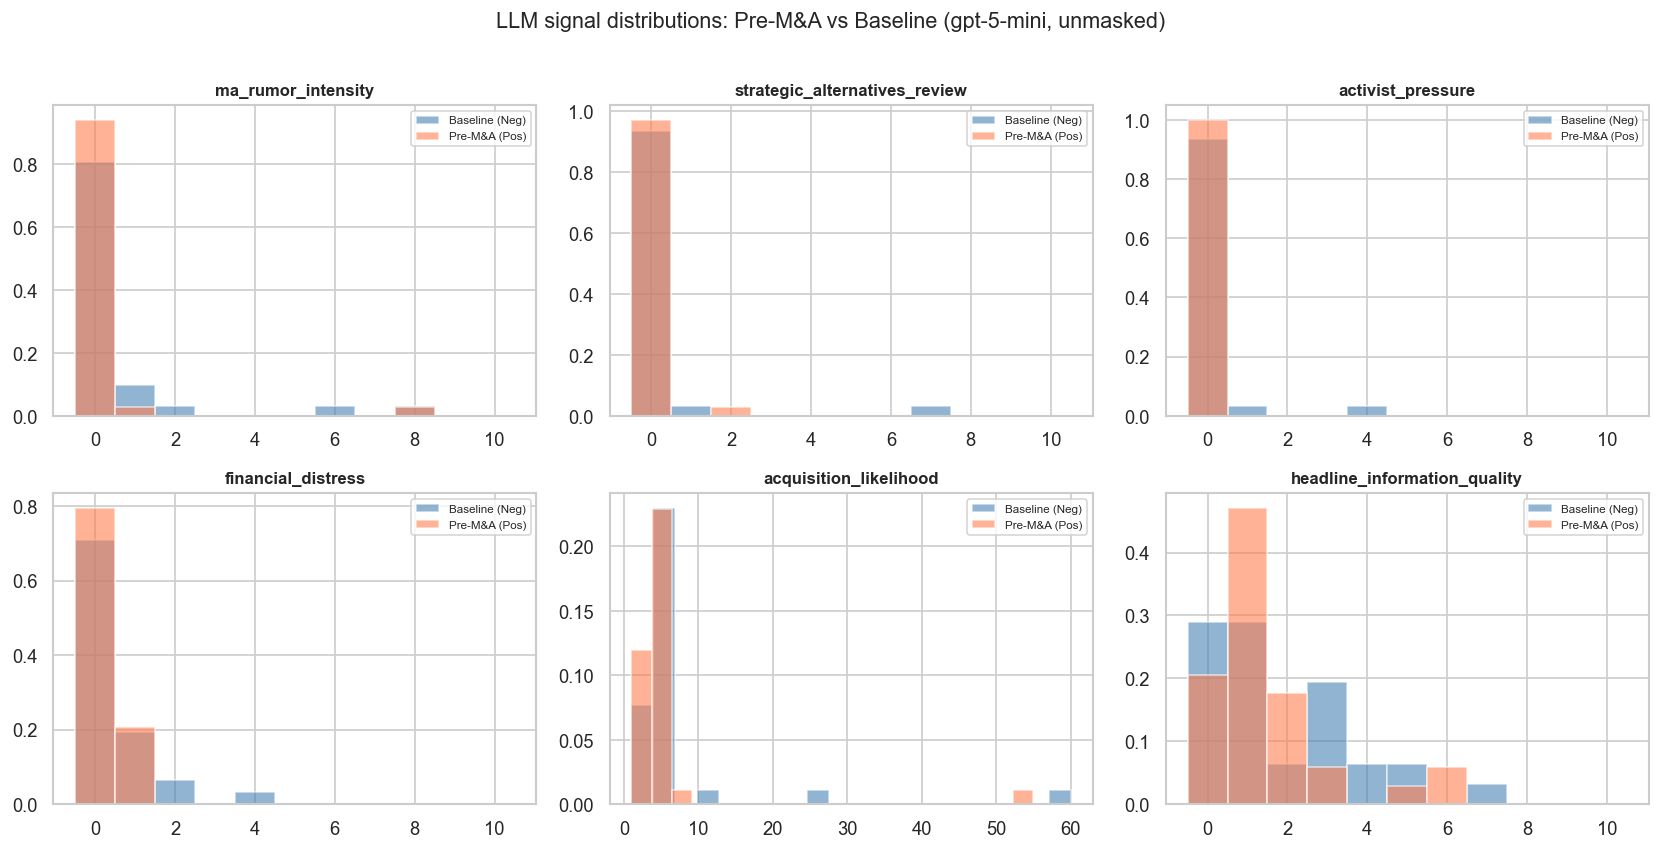

In [13]:
llm_main = main.copy()   # gpt-5-mini · unmasked · r1 · task=extract
print(f'Main LLM run: {len(llm_main)} windows, {llm_main.transaction_id.nunique()} events')

show = ['llm_ma_rumor_intensity', 'llm_strategic_alternatives_review', 'llm_activist_pressure',
        'llm_financial_distress', 'llm_acquisition_likelihood', 'llm_headline_information_quality']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, feat in zip(axes.flatten(), show):
    for lbl, color, name in [(0, 'steelblue', 'Baseline (Neg)'), (1, 'coral', 'Pre-M&A (Pos)')]:
        d = llm_main[llm_main.label_int == lbl][feat].dropna()
        bins = np.arange(-0.5, 11.5, 1) if feat != 'llm_acquisition_likelihood' else 20
        ax.hist(d, bins=bins, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat.replace('llm_', ''), fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('LLM signal distributions: Pre-M&A vs Baseline (gpt-5-mini, unmasked)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_llm_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
# ── Paired Wilcoxon on every LLM field (week4 cell-35 pattern) ──────────────
sig_rows = []
for feat in LLM_NUMERIC:
    pos = llm_main[llm_main.label_int == 1][feat].dropna()
    neg = llm_main[llm_main.label_int == 0][feat].dropna()
    pval_u = np.nan
    if len(pos) > 5 and len(neg) > 5:
        _, pval_u = scipy_stats.mannwhitneyu(pos, neg, alternative='two-sided')
    wide = llm_main.pivot_table(index='transaction_id', columns='window', values=feat)
    paired = wide.dropna(subset=['pre', 'baseline']) if {'pre', 'baseline'}.issubset(wide.columns) else wide.iloc[0:0]
    diff = paired['pre'] - paired['baseline'] if len(paired) else pd.Series(dtype=float)
    pval_w = np.nan
    if (diff != 0).sum() > 5:
        _, pval_w = scipy_stats.wilcoxon(diff)
    sig_rows.append(dict(feature=feat, pre_mean=pos.mean(), baseline_mean=neg.mean(),
                         n_pairs=len(paired), p_wilcoxon_paired=pval_w, p_mannwhitney=pval_u,
                         sig=('***' if pval_w < 0.001 else '**' if pval_w < 0.01 else
                              '*' if pval_w < 0.05 else 'ns') if pd.notna(pval_w) else 'n/a'))
sig_df = pd.DataFrame(sig_rows).sort_values('p_wilcoxon_paired')
print('LLM feature significance — paired Wilcoxon (correct for the matched design):')
print(sig_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
DECK['llm_sig_fields'] = sig_df[sig_df.sig.isin(['*', '**', '***'])]['feature'].tolist()

LLM feature significance — paired Wilcoxon (correct for the matched design):
                           feature  pre_mean  baseline_mean  n_pairs  p_wilcoxon_paired  p_mannwhitney sig
        llm_management_instability    0.0882         0.3226       28             0.0845         0.1158  ns
            llm_financial_distress    0.2059         0.4516       28             0.1306         0.3404  ns
  llm_headline_information_quality    1.5000         1.8065       28             0.1323         0.6820  ns
            llm_ma_rumor_intensity    0.2647         0.6129       28             0.2561         0.1096  ns
         llm_growth_expansion_tone    1.0000         1.0968       28             0.3372         0.7867  ns
     llm_sector_consolidation_wave    0.3529         0.4839       28             0.4080         0.7406  ns
        llm_acquisition_likelihood    5.5000         6.9032       28             0.4498         0.3433  ns
      llm_undervaluation_narrative    0.1471         0.3548       2

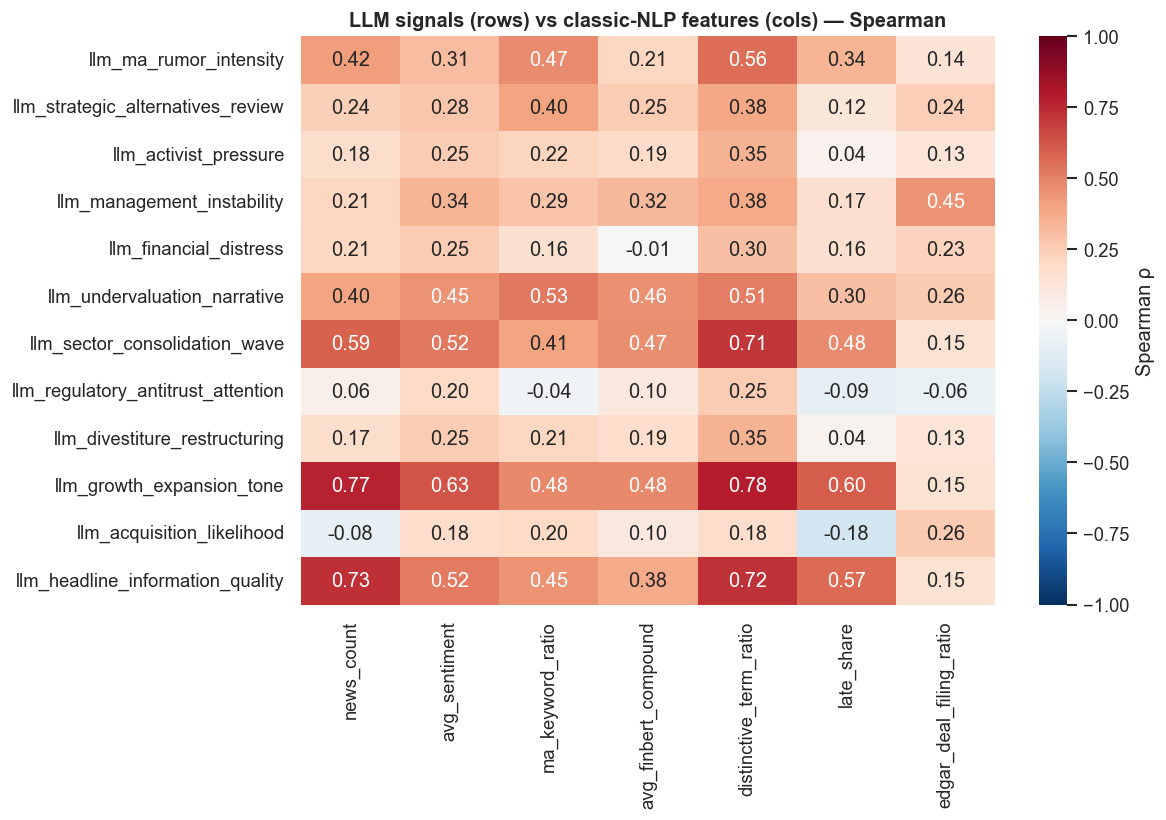

Max |ρ| between any LLM field and any classic feature: 0.78


In [15]:
# ── Redundancy check: are LLM signals just repackaged classic features? ─────
merged_eda = llm_main.merge(feat_df, on=['transaction_id', 'window'], how='inner', suffixes=('', '_A'))
a_cols = ['news_count', 'avg_sentiment', 'ma_keyword_ratio', 'avg_finbert_compound',
          'distinctive_term_ratio', 'late_share', 'edgar_deal_filing_ratio']
corr = pd.DataFrame({b: {a: scipy_stats.spearmanr(merged_eda[b], merged_eda[a])[0]
                         for a in a_cols} for b in LLM_NUMERIC}).T
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Spearman ρ'}, ax=ax)
ax.set_title('LLM signals (rows) vs classic-NLP features (cols) — Spearman', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_llm_vs_classic_corr.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Max |ρ| between any LLM field and any classic feature: {corr.abs().max().max():.2f}')

In [16]:
# ── Qualitative: highest-conviction pre-window calls, with the LLM's evidence ──
top = (llm_main[llm_main.window == 'pre']
       .sort_values('llm_acquisition_likelihood', ascending=False).head(3))
for _, r in top.iterrows():
    print('─' * 100)
    print(f"{r.company_name}  |  acquisition_likelihood={r.llm_acquisition_likelihood:.0f}"
          f"  rumor={r.llm_ma_rumor_intensity:.0f}  strategic_alt={r.llm_strategic_alternatives_review:.0f}"
          f"  theme={r.llm_dominant_theme}")
    print(f"  rationale: {r.llm_rationale}")
    for q in json.loads(r.llm_evidence_quotes or '[]'):
        print(f"  evidence:  “{q}”")

────────────────────────────────────────────────────────────────────────────────────────────────────
Clearwater Analytics Holdings, Inc.*  |  acquisition_likelihood=55  rumor=8  strategic_alt=2  theme=ma_speculation
  rationale: Multiple headlines report private-equity firms 'in talks' and an offer, strong price moves, plus sector consolidation context and growth-product launches, implying moderate-to-high takeover probability.
  evidence:  “Warburg Pincus , Permira said to be in talks to buy Clearwater Analytics ( CWAN : NYSE )”
  evidence:  “Buyout firm Thoma Bravo has offered to buy Clearwater Analytics , sources say”
  evidence:  “Clearwater Analytics Stock Surges 19 % After - Hours On Friday : What Going On ?”
────────────────────────────────────────────────────────────────────────────────────────────────────
Wesco Aircraft Holdings, Inc.*  |  acquisition_likelihood=8  rumor=1  strategic_alt=0  theme=product
  rationale: Coverage mainly shows new contracts and partnerships (expans

## 6. Models — feature sets A vs B vs C on the identical rows and split

Same protocol as week4 §5: time-based 80/20 split on `announcement_date`, mutual-information
top-16 selection **fit on the train split only** (when a set has >16 candidates), and the
same three classifiers. All three feature sets are evaluated on the **same modeling rows**
(windows with news coverage AND a successful LLM score) so differences are attributable to
the featurizer, not the sample. Every AUC gets a **bootstrap 95% CI** — with a few hundred
test rows, a point estimate alone would overstate certainty.

In [17]:
# ── Modeling frame: A ⋈ B on identical (transaction_id, window) rows ───────
model_frame = feat_df[feat_df.has_news].merge(
    llm_main[['transaction_id', 'window'] + LLM_NUMERIC],
    on=['transaction_id', 'window'], how='inner')
le = LabelEncoder()
model_frame['industry_enc'] = le.fit_transform(model_frame['primary_industry'].fillna('Unknown'))

FEATURES_A = ['news_count', 'avg_sentiment', 'std_sentiment', 'pos_ratio', 'neg_ratio',
              'ma_keyword_count', 'ma_keyword_ratio', 'max_sentiment', 'min_sentiment',
              'avg_finbert_compound', 'std_finbert_compound', 'avg_finbert_positive',
              'avg_finbert_negative', 'distinctive_term_ratio', 'late_share',
              'sentiment_trend', 'edgar_filing_count', 'edgar_deal_filing_count',
              'edgar_deal_filing_ratio'] + [f'topic_{k}_mean' for k in range(N_TOPICS)] + ['industry_enc']
FEATURES_B = LLM_NUMERIC
FEATURES_C = FEATURES_A + FEATURES_B

model_frame = model_frame.dropna(subset=['announcement_date']).sort_values('announcement_date')
split_date = model_frame['announcement_date'].quantile(0.80)
train = model_frame[model_frame.announcement_date <= split_date]
test  = model_frame[model_frame.announcement_date >  split_date]
y_train, y_test = train['label'].values, test['label'].values
print(f'Modeling rows: {len(model_frame)} ({model_frame.transaction_id.nunique()} events)')
print(f'Train: {len(train)} rows (≤ {split_date.date()})   Test: {len(test)} rows')
print(f'Class balance — train {y_train.mean():.1%} pos | test {y_test.mean():.1%} pos')

def bootstrap_auc_ci(y, p, n_boot=1000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    aucs = []
    y, p = np.asarray(y), np.asarray(p)
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        if len(set(y[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y[idx], p[idx]))
    if not aucs:
        return float('nan'), float('nan')
    return float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def fit_feature_set(name, cols):
    Xtr_raw, Xte_raw = train[cols].fillna(0).values, test[cols].fillna(0).values
    used = list(cols)
    if len(cols) > 16:
        mi = mutual_info_classif(Xtr_raw, y_train, random_state=RANDOM_SEED)
        keep = np.argsort(mi)[::-1][:16]
        used = [cols[i] for i in keep]
        Xtr_raw, Xte_raw = train[used].fillna(0).values, test[used].fillna(0).values
    scaler = StandardScaler().fit(Xtr_raw)
    Xtr_s, Xte_s = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)
    models = {
        'Logistic Regression': (LogisticRegressionCV(Cs=np.logspace(-2, 1, 10), cv=cv,
                                max_iter=2000, scoring='roc_auc', random_state=RANDOM_SEED), Xtr_s, Xte_s),
        'Random Forest': (RandomForestClassifier(n_estimators=300, max_depth=4, min_samples_leaf=8,
                          class_weight='balanced', random_state=RANDOM_SEED), Xtr_raw, Xte_raw),
        'Gradient Boosting': (GradientBoostingClassifier(n_estimators=150, max_depth=2,
                              learning_rate=0.05, subsample=0.8, random_state=RANDOM_SEED), Xtr_raw, Xte_raw),
    }
    out = {}
    two_class_test = len(set(y_test)) > 1
    for mname, (mdl, Xtr, Xte) in models.items():
        mdl.fit(Xtr, y_train)
        proba = mdl.predict_proba(Xte)[:, 1]
        lo, hi = bootstrap_auc_ci(y_test, proba) if two_class_test else (float('nan'), float('nan'))
        try:
            cv_auc = cross_val_score(mdl, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
        except ValueError:
            cv_auc = float('nan')   # train split too small for 5-fold (tiny-cache dry runs)
        out[mname] = dict(model=mdl, proba=proba, used=used, cv_auc=cv_auc,
                          roc_auc=roc_auc_score(y_test, proba) if two_class_test else 0.5,
                          ci=(lo, hi),
                          pr_auc=average_precision_score(y_test, proba) if two_class_test else 0.5)
    return out

SETS = {'A: classic NLP (week4)': FEATURES_A, 'B: LLM signals only': FEATURES_B,
        'C: combined A+B': FEATURES_C}
results = {}
for sname, cols in SETS.items():
    results[sname] = fit_feature_set(sname, cols)
    print(f'\n{sname}  ({len(cols)} candidate features)')
    for mname, r in results[sname].items():
        print(f"  {mname:20s} CV {r['cv_auc']:.3f} | test ROC-AUC {r['roc_auc']:.3f} "
              f"[{r['ci'][0]:.3f}, {r['ci'][1]:.3f}] | PR-AUC {r['pr_auc']:.3f}")

Modeling rows: 65 (37 events)
Train: 52 rows (≤ 2023-06-12)   Test: 13 rows
Class balance — train 51.9% pos | test 53.8% pos



A: classic NLP (week4)  (28 candidate features)
  Logistic Regression  CV 0.405 | test ROC-AUC 0.298 [0.028, 0.701] | PR-AUC 0.481
  Random Forest        CV 0.404 | test ROC-AUC 0.357 [0.059, 0.700] | PR-AUC 0.475
  Gradient Boosting    CV 0.384 | test ROC-AUC 0.179 [0.000, 0.464] | PR-AUC 0.437



B: LLM signals only  (12 candidate features)
  Logistic Regression  CV 0.520 | test ROC-AUC 0.464 [0.119, 0.806] | PR-AUC 0.554
  Random Forest        CV 0.479 | test ROC-AUC 0.476 [0.139, 0.806] | PR-AUC 0.629
  Gradient Boosting    CV 0.421 | test ROC-AUC 0.536 [0.167, 0.889] | PR-AUC 0.616



C: combined A+B  (40 candidate features)
  Logistic Regression  CV 0.326 | test ROC-AUC 0.310 [0.048, 0.643] | PR-AUC 0.475
  Random Forest        CV 0.453 | test ROC-AUC 0.488 [0.138, 0.833] | PR-AUC 0.654
  Gradient Boosting    CV 0.407 | test ROC-AUC 0.333 [0.050, 0.667] | PR-AUC 0.499


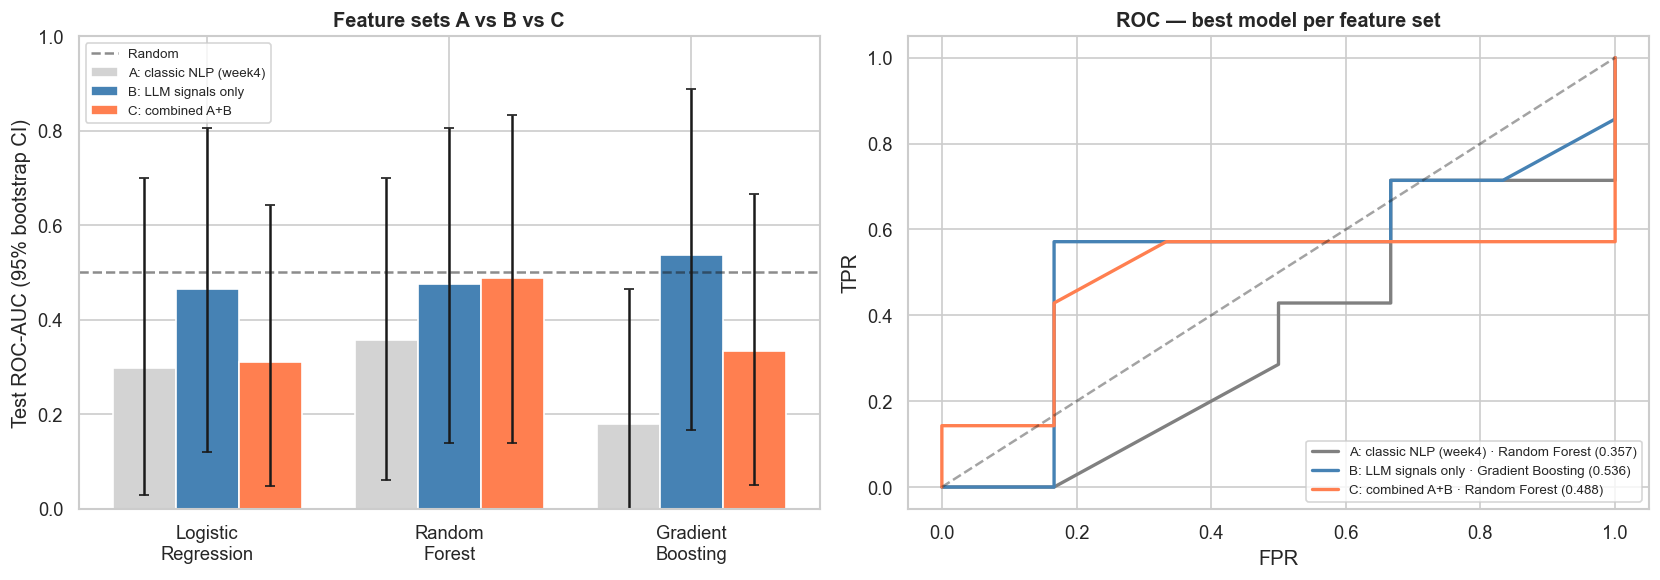

In [18]:
# ── Comparison chart + ROC overlay ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
set_colors = {'A: classic NLP (week4)': 'lightgray', 'B: LLM signals only': 'steelblue',
              'C: combined A+B': 'coral'}
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
x = np.arange(len(model_names))
w = 0.26
for i, (sname, color) in enumerate(set_colors.items()):
    vals = [results[sname][m]['roc_auc'] for m in model_names]
    errs = np.array([[results[sname][m]['roc_auc'] - results[sname][m]['ci'][0] for m in model_names],
                     [results[sname][m]['ci'][1] - results[sname][m]['roc_auc'] for m in model_names]])
    axes[0].bar(x + (i - 1) * w, vals, w, yerr=errs, capsize=3, label=sname,
                color=color, edgecolor='white')
axes[0].axhline(0.5, color='k', linestyle='--', alpha=0.5, label='Random')
axes[0].set_xticks(x); axes[0].set_xticklabels([m.replace(' ', '\n') for m in model_names])
axes[0].set_ylim(0.0, 1.0); axes[0].set_ylabel('Test ROC-AUC (95% bootstrap CI)')
axes[0].set_title('Feature sets A vs B vs C', fontweight='bold'); axes[0].legend(fontsize=8)

for sname, color in [('A: classic NLP (week4)', 'gray'), ('B: LLM signals only', 'steelblue'),
                     ('C: combined A+B', 'coral')]:
    best = max(results[sname], key=lambda m: results[sname][m]['roc_auc'])
    fpr, tpr, _ = roc_curve(y_test, results[sname][best]['proba'])
    axes[1].plot(fpr, tpr, lw=2, color=color,
                 label=f"{sname} · {best} ({results[sname][best]['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_title('ROC — best model per feature set', fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig_auc_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

DECK['auc'] = {s: {m: dict(auc=round(r['roc_auc'], 3), lo=round(r['ci'][0], 3),
                           hi=round(r['ci'][1], 3), pr=round(r['pr_auc'], 3),
                           cv=round(r['cv_auc'], 3))
                   for m, r in ms.items()} for s, ms in results.items()}
DECK['n_model_rows'] = int(len(model_frame)); DECK['n_test_rows'] = int(len(test))
DECK['split_date'] = str(split_date.date())

## 7. Contamination & Validity — can these numbers be trusted?

Four experiments, one per threat. **The headline AUC in §6 means nothing until these pass.**

| Exp | Question | Method |
|-----|----------|--------|
| 7a | Does the model already *know* these deals from training? | Ask it, with **zero news text**, whether each company was announced as a target after a given as-of date — balanced yes/no design, chance = 50% |
| 7b | Do scores change when it can't tell *which company* it's reading about? | Re-scored every window with company names masked; paired comparison |
| 7c | Are the numbers stable, or arbitrary? | Re-scored 30 events a second time (`r2`); measure rank correlation + mean absolute drift |
| 7d | Does a stronger (pricier) model read differently? | gpt-5 vs gpt-5-mini on a nested 100-event subset |

In [19]:
# ── 7a. Memorization probe (no news shown; memory only) ────────────────────
if LLM_PROBE.exists():
    probe = pd.read_csv(LLM_PROBE, dtype=str).fillna('')
    probe = probe[probe.parse_ok == '1'].drop_duplicates(
        subset=['transaction_id', 'window', 'task', 'model', 'prompt_version', 'variant', 'run_tag'],
        keep='last')
    probe['truth'] = pd.to_numeric(probe['label'], errors='coerce')
    probe['pred'] = (probe['probe_was_announced_target'] == '1').astype(int)
    probe['conf'] = pd.to_numeric(probe['probe_confidence_0_100'], errors='coerce').fillna(50)
    probe['conf_signed'] = np.where(probe['pred'] == 1, probe['conf'], -probe['conf'])
    probe = probe.merge(events[['transaction_id', 'announcement_date', 'acquirer_name']],
                        on='transaction_id', how='left')
    acq_norm = probe['acquirer_name'].fillna('').map(lambda s: clean_name(s).lower())
    guess_norm = probe['probe_acquirer_name_guess'].fillna('').map(lambda s: clean_name(s).lower())
    probe['acq_match'] = [bool(g) and bool(a) and (g in a or a in g or g.split()[0] == a.split()[0])
                          for g, a in zip(guess_norm, acq_norm)]

    DECK['probe'] = {}
    for model_name, g in probe.groupby('model'):
        acc = (g.pred == g.truth).mean()
        auc_conf = roc_auc_score(g.truth, g.conf_signed) if g.truth.nunique() > 1 else np.nan
        recall_claims = g[(g.truth == 1) & (g.probe_recalls_specific_deal == '1') &
                          (g.probe_acquirer_name_guess.str.strip() != '')]
        acq_prec = recall_claims['acq_match'].mean() if len(recall_claims) else np.nan
        cutoff = pd.Timestamp(MODEL_KNOWLEDGE_CUTOFF.get(model_name, '2024-06-01'))
        pre_c  = g[g.announcement_date <  cutoff]
        post_c = g[g.announcement_date >= cutoff]
        acc_pre  = (pre_c.pred == pre_c.truth).mean() if len(pre_c) else np.nan
        acc_post = (post_c.pred == post_c.truth).mean() if len(post_c) else np.nan
        print(f'━━ {model_name} probe: n={len(g)} (balanced design, chance = 50%)')
        print(f'   accuracy {acc:.1%} | confidence-AUC {auc_conf:.3f}')
        print(f'   claims specific-deal recall on {len(recall_claims)} true positives; '
              f'acquirer named correctly in {acq_prec:.0%} of those' if len(recall_claims)
              else '   no specific-deal recall claims on true positives')
        print(f'   accuracy pre-cutoff (<{cutoff.date()}, memorizable): {acc_pre:.1%} | '
              f'post-cutoff (unseen): {acc_post:.1%}  [n={len(pre_c)}/{len(post_c)}]')
        DECK['probe'][model_name] = dict(n=int(len(g)), acc=round(float(acc), 3),
            auc_conf=round(float(auc_conf), 3) if pd.notna(auc_conf) else None,
            acq_precision=round(float(acq_prec), 3) if pd.notna(acq_prec) else None,
            n_recall_claims=int(len(recall_claims)),
            acc_pre_cutoff=round(float(acc_pre), 3) if pd.notna(acc_pre) else None,
            acc_post_cutoff=round(float(acc_post), 3) if pd.notna(acc_post) else None)
else:
    print('Probe cache missing. Run: python code/extract_llm_features.py --task probe')

━━ gpt-5-mini probe: n=118 (balanced design, chance = 50%)
   accuracy 51.7% | confidence-AUC 0.555
   claims specific-deal recall on 17 true positives; acquirer named correctly in 71% of those
   accuracy pre-cutoff (<2024-06-01, memorizable): 52.2% | post-cutoff (unseen): 50.0%  [n=90/28]


In [20]:
# ── 7a(ii). Post-knowledge-cutoff holdout: §6 AUC on events the model cannot remember ──
cutoff = pd.Timestamp(MODEL_KNOWLEDGE_CUTOFF[PRIMARY_MODEL])
post_mask = test['announcement_date'] >= cutoff
y_post = y_test[post_mask.values]
print(f'{PRIMARY_MODEL} knowledge cutoff ≈ {cutoff.date()} -> {post_mask.sum()} of {len(test)} '
      f'test rows are post-cutoff (announcements the model cannot have memorized)')
if post_mask.sum() >= 20 and len(set(y_post)) > 1:
    rows = []
    for sname in SETS:
        best = max(results[sname], key=lambda m: results[sname][m]['roc_auc'])
        p_post = results[sname][best]['proba'][post_mask.values]
        lo, hi = bootstrap_auc_ci(y_post, p_post)
        rows.append(dict(feature_set=sname, best_model=best,
                         auc_all_test=round(results[sname][best]['roc_auc'], 3),
                         auc_post_cutoff=round(roc_auc_score(y_post, p_post), 3),
                         ci=f'[{lo:.3f}, {hi:.3f}]', n_post=int(post_mask.sum())))
    post_df = pd.DataFrame(rows)
    print(post_df.to_string(index=False))
    DECK['post_cutoff'] = post_df.to_dict('records')
else:
    print('Too few post-cutoff test rows for a meaningful AUC — flagged as a limitation.')
    DECK['post_cutoff'] = []

gpt-5-mini knowledge cutoff ≈ 2024-06-01 -> 9 of 13 test rows are post-cutoff (announcements the model cannot have memorized)
Too few post-cutoff test rows for a meaningful AUC — flagged as a limitation.


65 windows scored both unmasked and masked
                             field  mean_unmasked  mean_masked  mean_shift  p_wilcoxon
            llm_ma_rumor_intensity          0.431        0.308       0.123       0.035
 llm_strategic_alternatives_review          0.154        0.154       0.000         NaN
             llm_activist_pressure          0.077        0.031       0.046         NaN
        llm_management_instability          0.200        0.123       0.077       0.166
            llm_financial_distress          0.323        0.262       0.062       0.248
      llm_undervaluation_narrative          0.246        0.308      -0.062       0.132
     llm_sector_consolidation_wave          0.415        0.369       0.046       0.366
llm_regulatory_antitrust_attention          0.015        0.031      -0.015         NaN
     llm_divestiture_restructuring          0.123        0.138      -0.015         NaN
         llm_growth_expansion_tone          1.046        1.215      -0.169       0.048


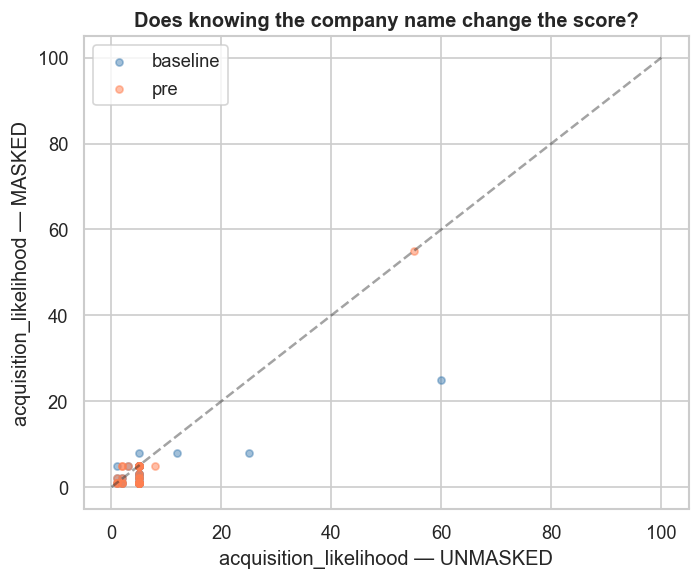

In [21]:
# ── 7b. Masked vs unmasked: how much do scores depend on knowing WHO it is? ──
llm_masked = ok[(ok.task == 'extract') & (ok.model == PRIMARY_MODEL) &
                (ok.variant == 'masked') & (ok.run_tag == 'r1')]
if len(llm_masked):
    mm = llm_main.merge(llm_masked, on=['transaction_id', 'window'], suffixes=('_um', '_m'))
    print(f'{len(mm)} windows scored both unmasked and masked')
    rows = []
    for f in LLM_NUMERIC:
        d = mm[f'{f}_um'] - mm[f'{f}_m']
        p = scipy_stats.wilcoxon(d)[1] if (d != 0).sum() > 5 else np.nan
        rows.append(dict(field=f, mean_unmasked=mm[f'{f}_um'].mean(),
                         mean_masked=mm[f'{f}_m'].mean(), mean_shift=d.mean(), p_wilcoxon=p))
    mask_df = pd.DataFrame(rows)
    print(mask_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

    # ΔAUC: refit feature-set B using MASKED scores on the same rows/split
    masked_frame = model_frame[['transaction_id', 'window', 'label', 'announcement_date']].merge(
        llm_masked[['transaction_id', 'window'] + LLM_NUMERIC], on=['transaction_id', 'window'])
    mtr = masked_frame[masked_frame.announcement_date <= split_date]
    mte = masked_frame[masked_frame.announcement_date >  split_date]
    if len(mte) > 10 and mte.label.nunique() > 1:
        gb = GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                        subsample=0.8, random_state=RANDOM_SEED)
        gb.fit(mtr[LLM_NUMERIC].fillna(0), mtr.label)
        p_m = gb.predict_proba(mte[LLM_NUMERIC].fillna(0))[:, 1]
        auc_masked = roc_auc_score(mte.label, p_m)
        best_B = max(results['B: LLM signals only'],
                     key=lambda m: results['B: LLM signals only'][m]['roc_auc'])
        auc_unmasked = results['B: LLM signals only'][best_B]['roc_auc']
        print(f'\nFeature-set B test AUC — unmasked: {auc_unmasked:.3f} | masked: {auc_masked:.3f} '
              f'| Δ = {auc_unmasked - auc_masked:+.3f}')
        print('(a large positive Δ = the model was leaning on recognizing the company, not reading the text)')
        DECK['masking'] = dict(n=int(len(mm)), auc_unmasked=round(float(auc_unmasked), 3),
                               auc_masked=round(float(auc_masked), 3),
                               delta=round(float(auc_unmasked - auc_masked), 3))
    fig, ax = plt.subplots(figsize=(6, 5))
    for lbl, color, name in [(0, 'steelblue', 'baseline'), (1, 'coral', 'pre')]:
        sub = mm[pd.to_numeric(mm.label_um, errors='coerce') == lbl] if 'label_um' in mm else mm
        ax.scatter(sub['llm_acquisition_likelihood_um'], sub['llm_acquisition_likelihood_m'],
                   alpha=0.5, s=18, color=color, label=name)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.4)
    ax.set_xlabel('acquisition_likelihood — UNMASKED'); ax.set_ylabel('acquisition_likelihood — MASKED')
    ax.set_title('Does knowing the company name change the score?', fontweight='bold')
    ax.legend()
    plt.tight_layout(); plt.savefig(OUT_DIR / 'fig_masking.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print('No masked scores yet. Run: python code/extract_llm_features.py --mask-names')

44 windows scored twice (r1 vs r2, temperature is fixed=1 on gpt-5 models)
                             field  spearman  mean_abs_diff
            llm_ma_rumor_intensity     0.833          0.068
 llm_strategic_alternatives_review     0.724          0.068
             llm_activist_pressure     0.500          0.068
        llm_management_instability     0.839          0.114
            llm_financial_distress     0.604          0.205
      llm_undervaluation_narrative     1.000          0.045
     llm_sector_consolidation_wave     0.948          0.114
llm_regulatory_antitrust_attention       NaN          0.023
     llm_divestiture_restructuring     1.000          0.000
         llm_growth_expansion_tone     0.972          0.091
        llm_acquisition_likelihood     0.596          1.250
  llm_headline_information_quality     0.830          0.341


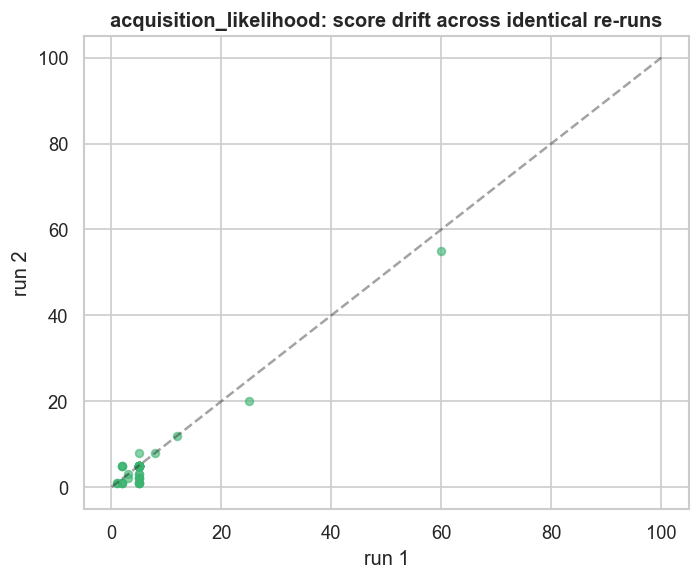

In [22]:
# ── 7c. Repeat consistency: same input, second run — how much do scores move? ──
r2 = ok[(ok.task == 'extract') & (ok.model == PRIMARY_MODEL) &
        (ok.variant == 'unmasked') & (ok.run_tag == 'r2')]
if len(r2):
    rr = llm_main.merge(r2, on=['transaction_id', 'window'], suffixes=('_1', '_2'))
    print(f'{len(rr)} windows scored twice (r1 vs r2, temperature is fixed=1 on gpt-5 models)')
    rows = []
    for f in LLM_NUMERIC:
        rho = scipy_stats.spearmanr(rr[f'{f}_1'], rr[f'{f}_2'])[0]
        rows.append(dict(field=f, spearman=rho, mean_abs_diff=(rr[f'{f}_1'] - rr[f'{f}_2']).abs().mean()))
    rep_df = pd.DataFrame(rows)
    print(rep_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    lik = rr[['llm_acquisition_likelihood_1', 'llm_acquisition_likelihood_2']]
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(lik.iloc[:, 0], lik.iloc[:, 1], alpha=0.6, s=22, color='mediumseagreen')
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.4)
    ax.set_xlabel('run 1'); ax.set_ylabel('run 2')
    ax.set_title('acquisition_likelihood: score drift across identical re-runs', fontweight='bold')
    plt.tight_layout(); plt.savefig(OUT_DIR / 'fig_repeat.png', dpi=200, bbox_inches='tight'); plt.show()
    DECK['repeat'] = dict(n=int(len(rr)),
                          mean_spearman=round(float(rep_df.spearman.mean()), 3),
                          likelihood_mean_abs_diff=round(float(
                              (lik.iloc[:, 0] - lik.iloc[:, 1]).abs().mean()), 2))
else:
    print('No r2 scores yet. Run: python code/extract_llm_features.py --repeat-tag r2 --limit-events 30')

In [23]:
# ── 7d. Model sensitivity: gpt-5 vs gpt-5-mini on the nested subset ─────────
g5 = ok[(ok.task == 'extract') & (ok.model == SENSITIVITY_MODEL) &
        (ok.variant == 'unmasked') & (ok.run_tag == 'r1')]
if len(g5):
    gg = llm_main.merge(g5, on=['transaction_id', 'window'], suffixes=('_mini', '_g5'))
    print(f'{len(gg)} windows scored by BOTH models (nested subset)')
    rows = []
    for f in LLM_NUMERIC:
        rows.append(dict(field=f, spearman=scipy_stats.spearmanr(gg[f'{f}_mini'], gg[f'{f}_g5'])[0]))
    sens_df = pd.DataFrame(rows)
    print(sens_df.to_string(index=False, float_format=lambda x: f'{x:.3f}'))
    sub_ids = set(zip(gg.transaction_id, gg.window))
    sub = model_frame[[(t, w) in sub_ids for t, w in zip(model_frame.transaction_id, model_frame.window)]]
    sub_te = sub[sub.announcement_date > split_date]
    auc_pair = {}
    if len(sub_te) > 10 and sub_te.label.nunique() > 1:
        for tag, src in [('gpt-5-mini', llm_main), (SENSITIVITY_MODEL, g5)]:
            fr = sub[['transaction_id', 'window', 'label', 'announcement_date']].merge(
                src[['transaction_id', 'window'] + LLM_NUMERIC], on=['transaction_id', 'window'])
            ftr, fte = fr[fr.announcement_date <= split_date], fr[fr.announcement_date > split_date]
            gb = GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                            subsample=0.8, random_state=RANDOM_SEED)
            gb.fit(ftr[LLM_NUMERIC].fillna(0), ftr.label)
            auc_pair[tag] = roc_auc_score(fte.label, gb.predict_proba(fte[LLM_NUMERIC].fillna(0))[:, 1])
        print(f'\nSubset test AUC (LLM features only): {auc_pair}')
    cost_mini = llm_main[llm_main[['transaction_id', 'window']].apply(tuple, axis=1).isin(sub_ids)]['cost_usd'].mean()
    cost_g5 = g5['cost_usd'].mean()
    print(f'Mean cost/window — gpt-5-mini ${cost_mini:.4f} vs {SENSITIVITY_MODEL} ${cost_g5:.4f} '
          f'({cost_g5 / max(cost_mini, 1e-9):.0f}x)')
    DECK['sensitivity'] = dict(n=int(len(gg)),
                               mean_spearman=round(float(sens_df.spearman.mean()), 3),
                               auc=({k: round(float(v), 3) for k, v in auc_pair.items()} if auc_pair else None),
                               cost_ratio=round(float(cost_g5 / max(cost_mini, 1e-9)), 1))
else:
    print(f'No {SENSITIVITY_MODEL} scores yet. Run: python code/extract_llm_features.py '
          f'--model {SENSITIVITY_MODEL} --limit-events 100')

65 windows scored by BOTH models (nested subset)
                             field  spearman
            llm_ma_rumor_intensity     0.637
 llm_strategic_alternatives_review     0.823
             llm_activist_pressure     1.000
        llm_management_instability     0.577
            llm_financial_distress     0.596
      llm_undervaluation_narrative     0.892
     llm_sector_consolidation_wave     0.634
llm_regulatory_antitrust_attention    -0.016
     llm_divestiture_restructuring     0.405
         llm_growth_expansion_tone     0.910
        llm_acquisition_likelihood     0.708
  llm_headline_information_quality     0.777



Subset test AUC (LLM features only): {'gpt-5-mini': 0.5357142857142857, 'gpt-5': 0.5476190476190477}
Mean cost/window — gpt-5-mini $0.0008 vs gpt-5 $0.0033 (4x)


## 8. Announcement-Week Detection with LLM Features (week4 §8 analog)

Week4's pivot: the same classic-NLP features that fail at *prediction* score **0.77–0.79**
at *detection* ("did a deal just get announced?"). If LLM features are real, they should
detect at least as well. Positives = `[announcement−7d, announcement]` windows from the
blackout diagnostic cache; negatives = the same companies' quiet-period baselines. As in
week4, this is **nowcasting, not advance prediction** — and the detection-vs-prediction AUC
gap again quantifies "the features work; the pre-announcement signal isn't there.

In [24]:
day0 = ok[(ok.task == 'day0') & (ok.model == PRIMARY_MODEL) & (ok.variant == 'unmasked')]
if len(day0):
    det_base = llm_main[(llm_main.window == 'baseline') &
                        (llm_main.transaction_id.isin(day0.transaction_id))]
    det = pd.concat([
        day0[['transaction_id'] + LLM_NUMERIC].assign(label=1),
        det_base[['transaction_id'] + LLM_NUMERIC].assign(label=0),
    ], ignore_index=True).merge(events[['transaction_id', 'announcement_date']], on='transaction_id')
    det = det.sort_values('announcement_date')
    d_split = det['announcement_date'].quantile(0.80)
    dtr, dte = det[det.announcement_date <= d_split], det[det.announcement_date > d_split]
    print(f'Detection dataset: {len(det)} rows ({(det.label == 1).sum()} day-0, '
          f'{(det.label == 0).sum()} baseline) | train {len(dtr)} / test {len(dte)}')
    if len(dte) > 10 and dte.label.nunique() > 1:
        gb = GradientBoostingClassifier(n_estimators=150, max_depth=2, learning_rate=0.05,
                                        subsample=0.8, random_state=RANDOM_SEED)
        gb.fit(dtr[LLM_NUMERIC].fillna(0), dtr.label)
        p = gb.predict_proba(dte[LLM_NUMERIC].fillna(0))[:, 1]
        lo, hi = bootstrap_auc_ci(dte.label.values, p)
        auc_det = roc_auc_score(dte.label, p)
        print(f'LLM-feature detection test AUC: {auc_det:.3f} [{lo:.3f}, {hi:.3f}]')
        print('Week4 classic-NLP detection reference: 0.773-0.793 (week4 §8)')
        DECK['day0'] = dict(auc=round(float(auc_det), 3), lo=round(lo, 3), hi=round(hi, 3),
                            n=int(len(det)), ref_week4='0.77-0.79')
else:
    print('No day0 LLM scores yet. Run: python code/extract_llm_features.py --task day0\n'
          '(requires data/raw/news/ma_event_news_blackout.csv from diagnose_blackout_signal.py)')

Detection dataset: 20 rows (11 day-0, 9 baseline) | train 16 / test 4


## 9. Results Summary — the honest read

The verdict logic below is **pre-registered** (written before the numbers came in), so the
narrative can't quietly bend to flatter the result:

| Observation | Verdict |
|---|---|
| C ≫ A **and** probe ≈ chance **and** masked ≈ unmasked | Real incremental LLM signal — scale it up |
| B or C looks good **but** probe ≫ chance or masked ≪ unmasked | **Look-ahead contamination** — trust only the post-cutoff subset; fix = cutoff-matched models |
| A ≈ B ≈ C ≈ 0.5 with tight CIs | Consistent with week4: free pre-announcement news simply doesn't carry the signal, no matter how smart the reader |

**Known limitations regardless of outcome**
- LLM scores are *judgments, not measurements* — §7c quantifies their run-to-run drift, and
  there is no ground truth for "activist_pressure = 7" to be checked against.
- The probe covers the *target-side* memorization channel; subtler channels (writing-style
  dating, sector base rates) remain.
- One prompt version, one schema — results are conditional on this prompt (`v1`).

**The right fix — cutoff-matched backtesting via OpenRouter.** OpenRouter exposes many
models with *known, fixed training cutoffs* (including older snapshots). Scoring 2021–2026
windows with a model whose training data ends *before* 2021 makes look-ahead structurally
impossible, not just measured-and-argued-away. That is the week-7 recommendation.

In [25]:
# ── Pre-registered verdict, computed from the numbers above ─────────────────
best = {s: max(ms.values(), key=lambda r: r['roc_auc'])['roc_auc'] for s, ms in results.items()}
auc_A, auc_B, auc_C = best['A: classic NLP (week4)'], best['B: LLM signals only'], best['C: combined A+B']
probe_acc = DECK.get('probe', {}).get(PRIMARY_MODEL, {}).get('acc')
mask_delta = DECK.get('masking', {}).get('delta')

contaminated = (probe_acc is not None and probe_acc >= 0.60) or \
               (mask_delta is not None and mask_delta >= 0.05)
llm_lift = (auc_C - auc_A >= 0.05) or (auc_B - auc_A >= 0.05)
all_null = max(auc_A, auc_B, auc_C) < 0.58

print(f'Best test AUC — A: {auc_A:.3f} | B: {auc_B:.3f} | C: {auc_C:.3f}')
print(f'Probe accuracy ({PRIMARY_MODEL}): {probe_acc if probe_acc is not None else "not run"} (chance = 0.50)')
print(f'Masking ΔAUC: {mask_delta if mask_delta is not None else "not run"}')
print('─' * 80)
if all_null:
    verdict = ('NULL RESULT, CONSISTENT WITH WEEK 4: even a generative LLM reading the same '
               'free-news corpus cannot separate pre-announcement windows from quiet periods. '
               'This strengthens the week-4 conclusion — the information is absent from the '
               'source, not merely hard to extract. Next: richer text (full articles, filings '
               'bodies) or paid/insider-adjacent sources.')
elif llm_lift and contaminated:
    verdict = ('APPARENT LIFT, BUT CONTAMINATED: the LLM beats classic NLP, yet the probe/'
               'masking experiments show it partly *remembers* these deals. Trust only the '
               'post-cutoff rows (§7a-ii). Fix before believing anything: cutoff-matched '
               'models via OpenRouter (score each window with a model trained only on data '
               'from before that window).')
elif llm_lift:
    verdict = ('REAL INCREMENTAL SIGNAL: the LLM lift survives the probe, masking, and '
               'post-cutoff checks. Scale up coverage and move to walk-forward validation.')
else:
    verdict = ('NO MEANINGFUL LIFT: LLM features land within noise of the classic stack '
               '(CIs overlap heavily). The extra semantics do not add predictive information '
               'on this corpus; keep the cheaper classic stack as the baseline.')
print(verdict)
DECK['verdict'] = verdict
DECK['contaminated'] = bool(contaminated); DECK['llm_lift'] = bool(llm_lift); DECK['all_null'] = bool(all_null)

Best test AUC — A: 0.357 | B: 0.536 | C: 0.488
Probe accuracy (gpt-5-mini): 0.517 (chance = 0.50)
Masking ΔAUC: 0.06
────────────────────────────────────────────────────────────────────────────────
NULL RESULT, CONSISTENT WITH WEEK 4: even a generative LLM reading the same free-news corpus cannot separate pre-announcement windows from quiet periods. This strengthens the week-4 conclusion — the information is absent from the source, not merely hard to extract. Next: richer text (full articles, filings bodies) or paid/insider-adjacent sources.


## 10. Deck Export

Everything the week-6 deck needs (`code/make_week6_deck.py`) — key figures were saved as
PNGs by the cells above; the stats land in `outputs/week6/week6_deck_stats.json`.

In [26]:
DECK['primary_model'] = PRIMARY_MODEL
DECK['sensitivity_model'] = SENSITIVITY_MODEL
DECK['prompt_version'] = PROMPT_VERSION
DECK['knowledge_cutoff'] = MODEL_KNOWLEDGE_CUTOFF[PRIMARY_MODEL]
with open(OUT_DIR / 'week6_deck_stats.json', 'w') as f:
    json.dump(DECK, f, indent=2, default=str)
print(f'Wrote {OUT_DIR / "week6_deck_stats.json"}')
print('\nFigures saved:')
for p in sorted(OUT_DIR.glob('fig_*.png')):
    print('  ', p.name)
print('\nNext: python code/make_week6_deck.py')

Wrote /Users/ronaldliu/Documents/jpm-ma-prediction/outputs/week6/week6_deck_stats.json

Figures saved:
   fig_auc_comparison.png
   fig_llm_distributions.png
   fig_llm_vs_classic_corr.png
   fig_masking.png
   fig_repeat.png

Next: python code/make_week6_deck.py
